Data Preprocessing

In [3]:
from google.colab import files
uploaded = files.upload()  # select all 5 CSVs

Saving comprehensive_foods_usda - Copy.csv to comprehensive_foods_usda - Copy.csv
Saving comprehensive_foods_usda.csv to comprehensive_foods_usda.csv
Saving foods_allergens - Copy.csv to foods_allergens - Copy.csv
Saving foods_allergens.csv to foods_allergens.csv
Saving foods_dietary_restrictions - Copy.csv to foods_dietary_restrictions - Copy.csv
Saving foods_dietary_restrictions.csv to foods_dietary_restrictions.csv
Saving foods_health_scores_allergens.csv to foods_health_scores_allergens.csv
Saving healthy_foods_database.csv to healthy_foods_database.csv


In [4]:
"""
Diet Recommendation System - Data Preprocessing Pipeline
Prepares USDA + OpenFoodFacts sourced food data for MLP classification
(predicting which health goal a food best serves), with allergen safety
flags and meal-slot tags for building a 4-meal daily plan.
"""

import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
ALLERGENS = ['gluten', 'dairy', 'nuts', 'soy', 'eggs', 'fish']
NUTRIENT_COLS = ['calories', 'protein_g', 'fat_g', 'carbs_g', 'fiber_g', 'sugar_g', 'sodium_mg']

KEYWORD_MAP = {
    'gluten': ['wheat', 'barley', 'rye', 'malt', 'gluten'],
    'dairy':  ['milk', 'cheese', 'cream', 'butter', 'whey', 'lactose', 'yogurt'],
    'nuts':   ['almond', 'walnut', 'cashew', 'pecan', 'hazelnut', 'pistachio', 'peanut', 'nut'],
    'soy':    ['soy', 'soybean', 'tofu'],
    'eggs':   ['egg'],
    'fish':   ['fish', 'salmon', 'tuna', 'shrimp', 'shellfish', 'crab', 'anchovy'],
}

MEAL_MORNING_KEYWORDS = ['cereal', 'oatmeal', 'toast', 'pancake', 'egg', 'yogurt', 'juice', 'coffee', 'tea']
MEAL_SNACK_KEYWORDS = ['chips', 'candy', 'cookie', 'nuts', 'popcorn', 'snack', 'bar', 'chocolate', 'cracker']


# ---------------------------------------------------------------------------
# 1. SAFE LOADING
# ---------------------------------------------------------------------------
def safe_read_csv(path, required_cols=None):
    """Load a CSV defensively: fail loudly and early with a clear message
    rather than letting a missing/renamed column blow up a later step."""
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        raise FileNotFoundError(
            f"Could not find '{path}'. Upload it to the Colab session first "
            f"(Files pane, or files.upload())."
        )
    df.columns = df.columns.str.strip()
    if required_cols:
        missing = set(required_cols) - set(df.columns)
        if missing:
            raise ValueError(
                f"'{path}' is missing expected column(s): {missing}. "
                f"Found columns: {list(df.columns)}"
            )
    return df


def to_bool_safe(series):
    """Handle allergen flag columns that may arrive as real bools, strings
    ('True'/'False'), or 1/0, without throwing on unexpected values."""
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map({'true': True, 'false': False, '1': True, '0': False})
    )


# ---------------------------------------------------------------------------
# 2. CLEAN EACH SOURCE
# ---------------------------------------------------------------------------
def clean_usda(path='comprehensive_foods_usda.csv'):
    df = safe_read_csv(path, required_cols=['food_name', 'food_category', 'calories'])
    df = df.drop_duplicates(subset=['food_name', 'food_category', 'calories'])

    rename = {'carbs_g': 'carbs_g', 'protein_g': 'protein_g', 'fat_g': 'fat_g',
              'fiber_g': 'fiber_g', 'sugar_g': 'sugar_g', 'sodium_mg': 'sodium_mg'}
    for c in ['food_name', 'food_category', 'ingredients', 'food_type']:
        if c in df.columns:
            df[c] = df[c].astype(str).str.strip().replace({'nan': np.nan})

    for c in NUTRIENT_COLS:
        if c not in df.columns:
            df[c] = np.nan
        df[c] = pd.to_numeric(df[c], errors='coerce')
        df[c] = df.groupby('food_category')[c].transform(lambda x: x.fillna(x.median()))
        df[c] = df[c].fillna(df[c].median())
        df[c] = df[c].clip(lower=0)

    if 'health_score' not in df.columns:
        df['health_score'] = np.nan
    df['health_score'] = pd.to_numeric(df['health_score'], errors='coerce')
    df['health_score'] = df['health_score'].fillna(df['health_score'].median())

    ingredients_lower = df.get('ingredients', pd.Series('', index=df.index)).fillna('').str.lower()
    for a in ALLERGENS:
        pattern = '|'.join(KEYWORD_MAP[a])
        df[f'contains_{a}'] = ingredients_lower.str.contains(pattern, regex=True, na=False)
    df['allergen_verified'] = df.get('ingredients', pd.Series(np.nan, index=df.index)).notna()

    df['category'] = df['food_category']
    df['source'] = 'usda'
    return df


def clean_healthy_db(path='healthy_foods_database.csv'):
    df = safe_read_csv(path, required_cols=['food_name', 'food_type', 'calories'])
    df = df.drop_duplicates(subset=['food_name', 'food_type', 'calories'])

    for c in NUTRIENT_COLS:
        if c not in df.columns:
            df[c] = np.nan
        df[c] = pd.to_numeric(df[c], errors='coerce')
        df[c] = df.groupby('food_type')[c].transform(lambda x: x.fillna(x.median()))
        df[c] = df[c].fillna(df[c].median())
        df[c] = df[c].clip(lower=0)

    if 'health_score' not in df.columns:
        df['health_score'] = np.nan
    df['health_score'] = pd.to_numeric(df['health_score'], errors='coerce')
    df['health_score'] = df['health_score'].fillna(df['health_score'].median())

    for a in ALLERGENS:
        df[f'contains_{a}'] = np.nan  # no ingredient data available -> unknown, not "safe"
    df['allergen_verified'] = False

    df['category'] = df['food_type']
    df['source'] = 'healthy_db'
    return df


def clean_openfoodfacts(path='foods_health_scores_allergens.csv'):
    df = safe_read_csv(path, required_cols=['product_name'])
    df = df.dropna(subset=['product_name'])
    dedup_keys = [c for c in ['product_name', 'brands'] if c in df.columns]
    df = df.drop_duplicates(subset=dedup_keys)

    if 'nutriscore_grade' in df.columns:
        df['nutriscore_grade'] = df['nutriscore_grade'].replace(
            {'UNKNOWN': np.nan, 'NOT-APPLICABLE': np.nan}
        )
    else:
        df['nutriscore_grade'] = np.nan

    if 'nova_group' not in df.columns:
        df['nova_group'] = np.nan
    df['nova_group'] = pd.to_numeric(df['nova_group'], errors='coerce')
    df['nova_group'] = df['nova_group'].fillna(df['nova_group'].median())

    off_nutrient_map = {
        'calories': 'energy_kcal', 'fat_g': 'fat_100g', 'carbs_g': 'carbs_100g',
        'sugar_g': 'sugars_100g', 'fiber_g': 'fiber_100g', 'protein_g': 'proteins_100g',
    }
    for target_col, src_col in off_nutrient_map.items():
        if src_col not in df.columns:
            df[src_col] = np.nan
        df[src_col] = pd.to_numeric(df[src_col], errors='coerce')
        df[src_col] = df[src_col].fillna(df[src_col].median())
        df[src_col] = df[src_col].clip(lower=0)
        df[target_col] = df[src_col]

    if 'sodium_100g' not in df.columns:
        df['sodium_100g'] = np.nan
    df['sodium_100g'] = pd.to_numeric(df['sodium_100g'], errors='coerce')
    df['sodium_100g'] = df['sodium_100g'].fillna(df['sodium_100g'].median()).clip(lower=0)
    df['sodium_mg'] = df['sodium_100g'] * 1000  # OFF stores sodium in grams/100g

    for a in ALLERGENS:
        col = f'contains_{a}'
        if col not in df.columns:
            df[col] = False
        df[col] = to_bool_safe(df[col]).fillna(False)
    df['allergen_verified'] = True

    df['food_name'] = df['product_name']
    df['category'] = df.get('categories', pd.Series(np.nan, index=df.index))
    df['health_score'] = np.nan  # not provided by this source
    df['source'] = 'openfoodfacts'
    return df


# ---------------------------------------------------------------------------
# 3. GOAL LABEL ENGINEERING (the MLP classification target)
# ---------------------------------------------------------------------------
def add_goal_labels(df):
    df = df.copy()
    c, p, f, cb, fb, s, so = (df['calories'], df['protein_g'], df['fat_g'],
                               df['carbs_g'], df['fiber_g'], df['sugar_g'], df['sodium_mg'])

    df['ws_weight_loss']     = (100 - c / 5) + fb * 3 - f * 2
    df['ws_muscle_gain']     = p * 4 - s
    df['ws_heart_health']    = (100 - so / 20) + fb * 2 - f
    df['ws_diabetic']        = (100 - s * 3 - cb) + fb * 4
    df['ws_balanced']        = 100 - (c - 250).abs() / 5 - (f - 15).abs() - (s - 10).abs()

    goal_cols = ['ws_weight_loss', 'ws_muscle_gain', 'ws_heart_health', 'ws_diabetic', 'ws_balanced']
    goal_names = {'ws_weight_loss': 'Weight Loss', 'ws_muscle_gain': 'Muscle Gain',
                  'ws_heart_health': 'Heart Health', 'ws_diabetic': 'Diabetic-Friendly',
                  'ws_balanced': 'Balanced Diet'}
    df['best_fit_goal'] = df[goal_cols].idxmax(axis=1).map(goal_names)
    return df


# ---------------------------------------------------------------------------
# 4. MEAL-SLOT ENGINEERING
# ---------------------------------------------------------------------------
def assign_meal_slot(row):
    name = str(row.get('food_name', '')).lower()
    ftype = row.get('category', '')
    ftype = ftype if isinstance(ftype, str) else ''

    if any(k in name for k in MEAL_MORNING_KEYWORDS):
        return 'Morning'
    if any(k in name for k in MEAL_SNACK_KEYWORDS) or 'Snacks' in ftype or 'Sweets' in ftype:
        return 'Snack'
    if any(k in ftype for k in ['Meat', 'Seafood', 'Grain', 'Vegetable']):
        return 'Afternoon'
    if any(k in ftype for k in ['Fruit', 'Dairy', 'Beverage']):
        return 'Morning'
    return 'Afternoon'


# ---------------------------------------------------------------------------
# 5. MERGE
# ---------------------------------------------------------------------------
def build_master(usda, healthy, off):
    common_cols = (['food_name', 'category', 'source', 'health_score', 'allergen_verified']
                   + NUTRIENT_COLS + [f'contains_{a}' for a in ALLERGENS])

    for df in (usda, healthy, off):
        for c in common_cols:
            if c not in df.columns:
                df[c] = np.nan

    master = pd.concat([usda[common_cols], healthy[common_cols], off[common_cols]],
                        ignore_index=True)
    master = master.dropna(subset=['food_name'])
    master['food_name'] = master['food_name'].astype(str).str.strip()
    master = master[master['food_name'].str.len() > 0]
    return master


# ---------------------------------------------------------------------------
# 6. FINAL CLEANUP BEFORE MODELING
# ---------------------------------------------------------------------------
def finalize_for_mlp(master):
    df = master.copy()

    # Nutrients: fill any remaining gaps per-source, then guarantee zero NaNs
    for c in NUTRIENT_COLS:
        df[c] = df.groupby('source')[c].transform(lambda x: x.fillna(x.median()))
        df[c] = df[c].fillna(df[c].median()).fillna(0)
        # IQR outlier clipping, done per-source so the very different ranges
        # of USDA vs OpenFoodFacts data don't distort each other's bounds
        for src in df['source'].unique():
            mask = df['source'] == src
            Q1, Q3 = df.loc[mask, c].quantile(0.25), df.loc[mask, c].quantile(0.75)
            IQR = Q3 - Q1
            if IQR > 0:
                df.loc[mask, c] = df.loc[mask, c].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

    # health_score: rescale to a common 0-100 range per source, fill blanks with median
    df['health_score'] = pd.to_numeric(df['health_score'], errors='coerce')
    for src in df['source'].unique():
        mask = df['source'] == src
        col = df.loc[mask, 'health_score']
        if col.notna().sum() > 0 and col.max() > col.min():
            df.loc[mask, 'health_score'] = 100 * (col - col.min()) / (col.max() - col.min())
    df['health_score'] = df['health_score'].fillna(df['health_score'].median()).fillna(50)

    # Allergen flags: cast to a 3-state numeric code so nothing is ever a raw
    # bool/string mix that sklearn would reject.
    # 0 = confirmed absent, 1 = confirmed present, -1 = unknown/unverified
    for a in ALLERGENS:
        col = f'contains_{a}'
        df[col] = df[col].map({True: 1, False: 0}).fillna(-1).astype(int)

    df['category'] = df['category'].fillna('Uncategorized').astype(str)
    df['allergen_verified'] = df['allergen_verified'].fillna(False).astype(bool)

    # Goal + meal-slot engineered labels
    df = add_goal_labels(df)
    df['meal_slot'] = df.apply(assign_meal_slot, axis=1)

    # Final safety net: no NaN/inf anywhere in numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

    df = df.drop_duplicates(subset=['food_name', 'source']).reset_index(drop=True)
    return df


# ---------------------------------------------------------------------------
# 7. ENCODE + SCALE + SPLIT  (fit only on train, reused on test -> no leakage,
#    no "unseen category" errors later at inference time)
# ---------------------------------------------------------------------------
def prepare_mlp_data(df, target_col='best_fit_goal', test_size=0.2):
    feature_cols = NUTRIENT_COLS + ['health_score'] + [f'contains_{a}' for a in ALLERGENS]

    X = df[feature_cols].copy()
    y = df[target_col].copy()

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=test_size, random_state=RANDOM_STATE, stratify=y_encoded
    )

    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)   # fit on train ONLY
    X_test_scaled = scaler.transform(X_test)          # reuse the same fit on test

    return {
        'X_train': X_train_scaled, 'X_test': X_test_scaled,
        'y_train': y_train, 'y_test': y_test,
        'feature_cols': feature_cols,
        'scaler': scaler, 'label_encoder': label_encoder,
    }


# ---------------------------------------------------------------------------
# MAIN
# ---------------------------------------------------------------------------
def run_pipeline():
    usda = clean_usda()
    healthy = clean_healthy_db()
    off = clean_openfoodfacts()

    master = build_master(usda, healthy, off)
    final_df = finalize_for_mlp(master)

    assert final_df.isnull().sum().sum() == 0, "NaNs remain after cleaning!"
    assert not np.isinf(final_df.select_dtypes(include=[np.number]).values).any(), "Infs remain!"

    mlp_data = prepare_mlp_data(final_df, target_col='best_fit_goal')

    final_df.to_csv('master_food_dataset_clean.csv', index=False)
    joblib.dump(mlp_data['scaler'], 'scaler.joblib')
    joblib.dump(mlp_data['label_encoder'], 'label_encoder.joblib')
    joblib.dump(mlp_data['feature_cols'], 'feature_cols.joblib')

    print("Pipeline finished with no errors.")
    print("Final dataset shape:", final_df.shape)
    print("Class balance (best_fit_goal):\n", final_df['best_fit_goal'].value_counts())
    print("Meal slot balance:\n", final_df['meal_slot'].value_counts())
    print("X_train shape:", mlp_data['X_train'].shape, "| X_test shape:", mlp_data['X_test'].shape)

    return final_df, mlp_data


if __name__ == '__main__':
    run_pipeline()

Pipeline finished with no errors.
Final dataset shape: (42860, 25)
Class balance (best_fit_goal):
 best_fit_goal
Heart Health         20702
Diabetic-Friendly    13489
Muscle Gain           3431
Balanced Diet         2823
Weight Loss           2415
Name: count, dtype: int64
Meal slot balance:
 meal_slot
Afternoon    27978
Snack         8248
Morning       6634
Name: count, dtype: int64
X_train shape: (34288, 14) | X_test shape: (8572, 14)


In [5]:
final_df, mlp_data = run_pipeline()

Pipeline finished with no errors.
Final dataset shape: (42860, 25)
Class balance (best_fit_goal):
 best_fit_goal
Heart Health         20702
Diabetic-Friendly    13489
Muscle Gain           3431
Balanced Diet         2823
Weight Loss           2415
Name: count, dtype: int64
Meal slot balance:
 meal_slot
Afternoon    27978
Snack         8248
Morning       6634
Name: count, dtype: int64
X_train shape: (34288, 14) | X_test shape: (8572, 14)


In [6]:
import numpy as np
import joblib
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [7]:
CONTINUOUS_FEATURES = ['calories','protein_g','fat_g','carbs_g','fiber_g','sugar_g','sodium_mg','health_score']
CATEGORICAL_FEATURES = ['contains_gluten','contains_dairy','contains_nuts','contains_soy','contains_eggs','contains_fish']

X_cont = final_df[CONTINUOUS_FEATURES].values
X_cat = final_df[CATEGORICAL_FEATURES].values
y = final_df['best_fit_goal'].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

Xc_train, Xc_test, Xcat_train, Xcat_test, y_train, y_test = train_test_split(
    X_cont, X_cat, y_encoded,
    test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train size:", Xc_train.shape[0], "| Test size:", Xc_test.shape[0])

Train size: 34288 | Test size: 8572


In [8]:
scaler = MinMaxScaler()
Xc_train_scaled = scaler.fit_transform(Xc_train)   # fit on train only
Xc_test_scaled = scaler.transform(Xc_test)          # reuse the same fit on test

Feature Extraction

In [9]:
pca = PCA(n_components=0.95, random_state=42)   # keep enough components for 95% of the variance
Xc_train_pca = pca.fit_transform(Xc_train_scaled)
Xc_test_pca = pca.transform(Xc_test_scaled)

print("Original continuous features:", len(CONTINUOUS_FEATURES))
print("PCA components kept:", Xc_train_pca.shape[1])
print("Variance explained:", pca.explained_variance_ratio_.sum())

# Recombine PCA-extracted features with the untouched allergen flags
X_train = np.hstack([Xc_train_pca, Xcat_train])
X_test = np.hstack([Xc_test_pca, Xcat_test])

Original continuous features: 8
PCA components kept: 7
Variance explained: 0.9795715079581778


In [10]:
Classification

NameError: name 'Classification' is not defined

In [11]:
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=15
)
mlp_clf.fit(X_train, y_train)
print("Training complete.")

Training complete.


Accuracy: 0.9597526831544564

Classification Report:

                   precision    recall  f1-score   support

    Balanced Diet       0.91      0.88      0.89       565
Diabetic-Friendly       0.97      0.95      0.96      2698
     Heart Health       0.97      0.98      0.97      4140
      Muscle Gain       0.96      0.96      0.96       686
      Weight Loss       0.89      0.93      0.91       483

         accuracy                           0.96      8572
        macro avg       0.94      0.94      0.94      8572
     weighted avg       0.96      0.96      0.96      8572



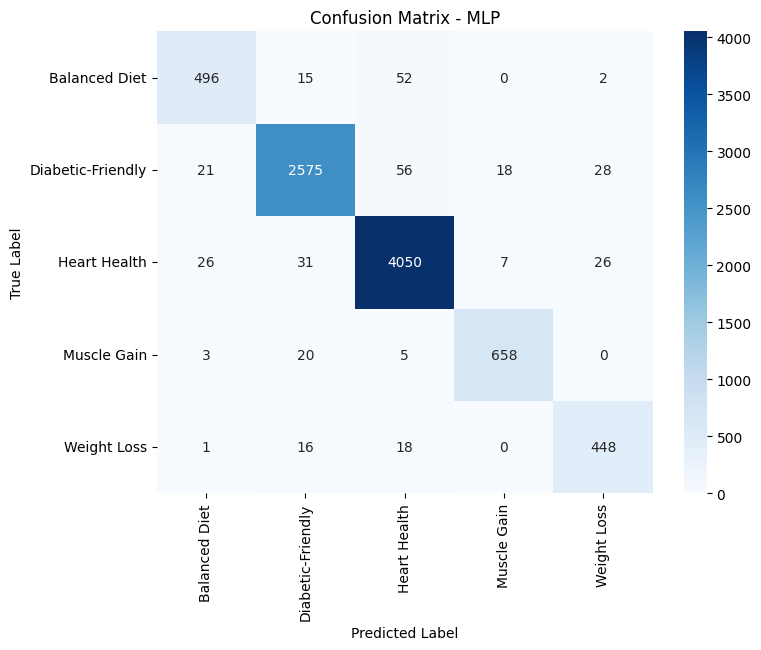

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = mlp_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - MLP")
plt.show()

In [13]:
joblib.dump(mlp_clf, 'mlp_classifier.joblib')
joblib.dump(scaler, 'pca_scaler.joblib')
joblib.dump(pca, 'pca_transform.joblib')
joblib.dump(label_encoder, 'goal_label_encoder.joblib')
print("Saved: mlp_classifier.joblib, pca_scaler.joblib, pca_transform.joblib, goal_label_encoder.joblib")

Saved: mlp_classifier.joblib, pca_scaler.joblib, pca_transform.joblib, goal_label_encoder.joblib


In [14]:
def predict_goal_for_food(food_row):
    x_cont = np.array([[food_row[c] for c in CONTINUOUS_FEATURES]])
    x_cat = np.array([[food_row[c] for c in CATEGORICAL_FEATURES]])
    x_cont_scaled = scaler.transform(x_cont)
    x_cont_pca = pca.transform(x_cont_scaled)
    x_final = np.hstack([x_cont_pca, x_cat])
    pred = mlp_clf.predict(x_final)[0]
    proba = mlp_clf.predict_proba(x_final)[0]
    label = label_encoder.inverse_transform([pred])[0]
    return label, dict(zip(label_encoder.classes_, proba))

Rule-based allergen filter

In [15]:
def filter_by_allergens(df, user_allergies, strict=True):
    """
    user_allergies: list like ['nuts', 'dairy']
    strict=True excludes both confirmed-present (1) AND unverified (-1) foods,
    since 'unknown' should never be treated as 'safe' for an allergy.
    strict=False only excludes confirmed-present (1) -> lets unverified foods through.
    """
    if not user_allergies:
        return df.copy()
    mask = pd.Series(True, index=df.index)
    for a in user_allergies:
        col = f'contains_{a}'
        if col not in df.columns:
            continue
        if strict:
            mask &= (df[col] == 0)
        else:
            mask &= (df[col] != 1)
    return df[mask].copy()

Multi Criteria Food Scoring

In [16]:
GOAL_WEIGHT_COL = {
    'Weight Loss': 'ws_weight_loss',
    'Muscle Gain': 'ws_muscle_gain',
    'Heart Health': 'ws_heart_health',
    'Diabetic-Friendly': 'ws_diabetic',
    'Balanced Diet': 'ws_balanced',
}

def score_foods_multi_criteria(df, goal_weights):
    """
    goal_weights: dict, e.g. {'Weight Loss': 0.7, 'Heart Health': 0.3}
    Normalizes each ws_ column to 0-1 (so scales don't dominate each other),
    then takes the weighted sum.
    """
    df = df.copy()
    total_weight = sum(goal_weights.values())
    score = pd.Series(0.0, index=df.index)
    for goal, w in goal_weights.items():
        col = GOAL_WEIGHT_COL[goal]
        col_min, col_max = df[col].min(), df[col].max()
        norm = (df[col] - col_min) / (col_max - col_min) if col_max > col_min else 0.5
        score += (w / total_weight) * norm
    df['recommendation_score'] = score
    return df

In [17]:
def recommend_daily_plan(df, user_goals, user_allergies, top_n_per_slot=3, strict_allergens=True):
    """
    user_goals: dict of goal -> weight, e.g. {'Weight Loss': 1.0}
    user_allergies: list, e.g. ['nuts', 'gluten']
    Returns {'Morning': [...], 'Afternoon': [...], 'Snack': [...]}
    """
    safe_df = filter_by_allergens(df, user_allergies, strict=strict_allergens)
    if safe_df.empty:
        return {'Morning': [], 'Afternoon': [], 'Snack': []}

    scored_df = score_foods_multi_criteria(safe_df, user_goals)

    plan = {}
    for slot in ['Morning', 'Afternoon', 'Snack']:
        slot_df = scored_df[scored_df['meal_slot'] == slot]
        top = slot_df.sort_values('recommendation_score', ascending=False).head(top_n_per_slot)
        cols = ['food_name', 'category', 'recommendation_score'] + [f'contains_{a}' for a in ALLERGENS]
        plan[slot] = top[cols].to_dict('records')
    return plan

In [18]:
user_goals = {'Weight Loss': 1.0}
user_allergies = ['nuts', 'dairy']

plan = recommend_daily_plan(final_df, user_goals, user_allergies, top_n_per_slot=3)

for slot, items in plan.items():
    print(f"\n=== {slot} ===")
    for item in items:
        print(f"  {item['food_name']}  (score={item['recommendation_score']:.3f})")


=== Morning ===
  AMAZONAS RAINFOREST PRODUCT, 100% NATURAL EMOLIENTE MIXED HERB TEA  (score=1.000)
  APPLE & CINNAMON MORINGA ORGANIC SUPERFOOD TEA BAGS, APPLE & CINNAMON  (score=1.000)
  100% LIME JUICE, LIME  (score=0.968)

=== Afternoon ===
  ALWAYS SAVE, DOUBLE ACTING BAKING POWDER  (score=1.000)
  AGAR AGAR SEA VEGETABLE FLAKES  (score=1.000)
  AGAR-AGAR POWDER  (score=1.000)

=== Snack ===
  BANANA FREEZE DRIED CRISPS, BANANA  (score=1.000)
  BARLEY FLAKES  (score=0.970)
  APPLE, SPINACH KIWI & KALE FRUIT & VEG SNACK, APPLE, SPINACH KIWI & KALE  (score=0.948)


FrontEnd part

In [22]:
!git config --global user.name "DivyaNageswari"
!git config --global user.email "guttikondadivya22@gmail.com"
!git clone https://github.com/DivyaNageswari/Diet-Recommendation-System.git
%cd Diet-Recommendation-System
!cp Project.ipynb .
!git add .
!git commit -m "Add project code"
!git push origin main

Cloning into 'Diet-Recommendation-System'...
/content/Diet-Recommendation-System
cp: cannot stat 'Project.ipynb': No such file or directory
On branch main

Initial commit

nothing to commit (create/copy files and use "git add" to track)
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/DivyaNageswari/Diet-Recommendation-System.git'


In [23]:
!ls -lah /content

total 64M
drwxr-xr-x 1 root root 4.0K Oct  8 08:29  .
drwxr-xr-x 1 root root 4.0K Oct  8 07:46  ..
-rw-r--r-- 1 root root  19M Oct  5 17:44  cloudflared-linux-amd64.deb
-rw-r--r-- 1 root root  16M Oct  8 08:02 'comprehensive_foods_usda - Copy.csv'
-rw-r--r-- 1 root root  16M Oct  8 08:02  comprehensive_foods_usda.csv
drwxr-xr-x 4 root root 4.0K Oct  2 13:50  .config
drwxr-xr-x 3 root root 4.0K Oct  8 08:29  Diet-Recommendation-System
-rw-r--r-- 1 root root  202 Oct  8 08:03  feature_cols.joblib
-rw-r--r-- 1 root root 295K Oct  8 08:02 'foods_allergens - Copy.csv'
-rw-r--r-- 1 root root 295K Oct  8 08:02  foods_allergens.csv
-rw-r--r-- 1 root root 675K Oct  8 08:02 'foods_dietary_restrictions - Copy.csv'
-rw-r--r-- 1 root root 675K Oct  8 08:02  foods_dietary_restrictions.csv
-rw-r--r-- 1 root root 2.0M Oct  8 08:02  foods_health_scores_allergens.csv
-rw-r--r-- 1 root root  552 Oct  8 08:04  goal_label_encoder.joblib
-rw-r--r-- 1 root root 826K Oct  8 08:02  healthy_foods_database.csv
-

In [24]:
!find /content -name "*.ipynb"